# Split Datasets For BERT - Stage 1

Split dataset to Train/Validation/Test sets for BERT

## A. Overview

ration 80:10:10


In [1]:
from pathlib import Path
import csv
import os
import random

from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

import configuration
from src import data_utils, setup

random.seed(setup.RANDOM_SEED)

## B. Load Datasets

In [2]:
dataset_path = Path("..") / "data"
# disaster_path = dataset_path / "disaster"
# extended_filepath = dataset_path / "extended"
splitted_filepath = dataset_path / "splitted"

In [3]:
df = pd.read_csv(splitted_filepath / "bert_sets.csv").sample(
    frac=1, random_state=setup.RANDOM_SEED
)

df_disaster = df[df["subset"] == "disaster"]
df_humanitarian = df_disaster[~df_disaster["humanitarian_label"].isna()]
df_weather = df[df["subset"] == "weather"]
df_out_topic = df[df["subset"] == "out_topic"]


/tmp/ipykernel_3405/3241162088.py:1: DtypeWarning: Columns (0: humanitarian_label) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(splitted_filepath / "bert_sets.csv").sample(


In [4]:
print(f"Base disaster dataset size: {df_disaster.groupby('informative').size()}")
print(
    f"Base humanitarian dataset size: {df_humanitarian.groupby('informative').size()}"
)
print(f"Base weather dataset size: {len(df_weather)}")
print(f"Base out-topic dataset size: {len(df_out_topic)}")

Base disaster dataset size: informative
False    5490
True     8886
dtype: int64
Base humanitarian dataset size: informative
False    2524
True     5943
dtype: int64
Base weather dataset size: 2578
Base out-topic dataset size: 177720


## C. Split multiple sets for BERT

In [5]:
def create_experiment_datasets(
    df_disaster_original,
    df_weather_original,
    df_out_topic_original,
    weather_ratio,
    out_topic_ratio,
):
    print(f"Weather ratio: {weather_ratio}, Out-topic ratio: {out_topic_ratio}")

    df_experiment_weather = df_weather_original.sample(
        frac=weather_ratio, random_state=setup.RANDOM_SEED
    )
    print(f"Weather samples: {len(df_weather_original)}")
    print(f"Weather experiment samples: {len(df_experiment_weather)}")

    df_experiment_out_topic = df_out_topic_original.sample(
        frac=out_topic_ratio, random_state=setup.RANDOM_SEED
    )
    print(f"Out-topic samples: {len(df_out_topic_original)}")
    print(f"Out-topic experiment samples: {len(df_experiment_out_topic)}")

    df_experiment = pd.concat(
        [df_disaster_original, df_experiment_weather, df_experiment_out_topic], ignore_index=True
    ).sample(
        frac=data_utils.DATA_FRACTION, random_state=setup.RANDOM_SEED
    ).reset_index(drop=True)

    return df_experiment


def split_then_export_datasets(
    df, validation_sizes=0.1, test_sizes=0.1, save_path: Path = None
):
    df_train, df_validation = train_test_split(
        df,
        test_size=validation_sizes + test_sizes,
        random_state=setup.RANDOM_SEED,
        stratify=df["informative"],
    )
    df_validation, df_test = train_test_split(
        df_validation,
        test_size=test_sizes / (validation_sizes + test_sizes),
        random_state=setup.RANDOM_SEED,
        stratify=df_validation["informative"],
    )
    save_path.mkdir(parents=True, exist_ok=True)
    df_train.to_csv(
        save_path / "train.csv", index=False, quoting=csv.QUOTE_ALL
    )

    df_validation.to_csv(
        save_path / "validation.csv",
        index=False,
        quoting=csv.QUOTE_ALL,
    )

    df_test.to_csv(
        save_path / "test.csv", index=False, quoting=csv.QUOTE_ALL
    )

    print(len(df_train))
    print(len(df_validation))
    print(len(df_test))

    # ration between train, validation, and test sets
    total = len(df_train) + len(df_validation) + len(df_test)
    print(f"Train: {len(df_train) / total:.2%}")
    print(f"Validation: {len(df_validation) / total:.2%}")
    print(f"Test: {len(df_test) / total:.2%}")

    dist = pd.DataFrame(
        {
            "Train": df_train["informative"].value_counts(normalize=True).sort_index(),
            "Validation": df_validation["informative"]
            .value_counts(normalize=True)
            .sort_index(),
            "Test": df_test["informative"].value_counts(normalize=True).sort_index(),
        }
    ).fillna(0)

    subset_dist = pd.DataFrame(
        {
            "Train": df_train[["informative", "subset"]]
            .value_counts(normalize=True)
            .sort_index(),
            "Validation": df_validation[["informative", "subset"]]
            .value_counts(normalize=True)
            .sort_index(),
            "Test": df_test[["informative", "subset"]]
            .value_counts(normalize=True)
            .sort_index(),
        }
    ).fillna(0)

    return dist, subset_dist

Weather ratio: 0, Out-topic ratio: 0
Weather samples: 2578
Weather experiment samples: 0
Out-topic samples: 177720
Out-topic experiment samples: 0
Experiment Dataset size: 14376
11500
1438
1438
Train: 79.99%
Validation: 10.00%
Test: 10.00%


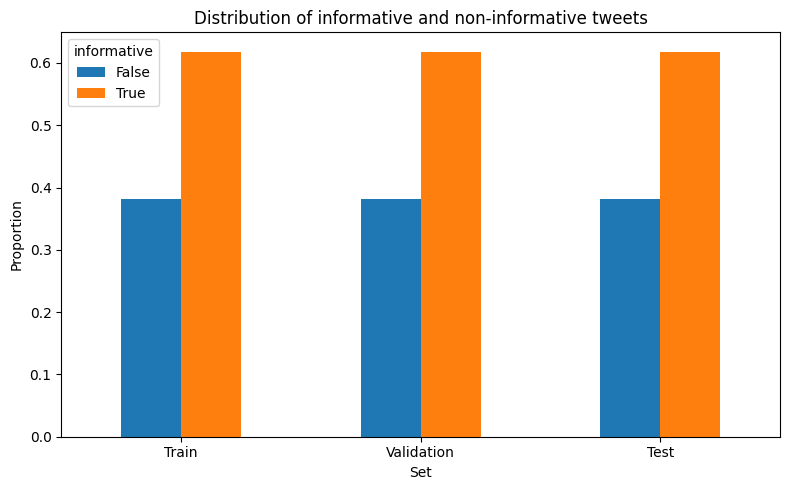

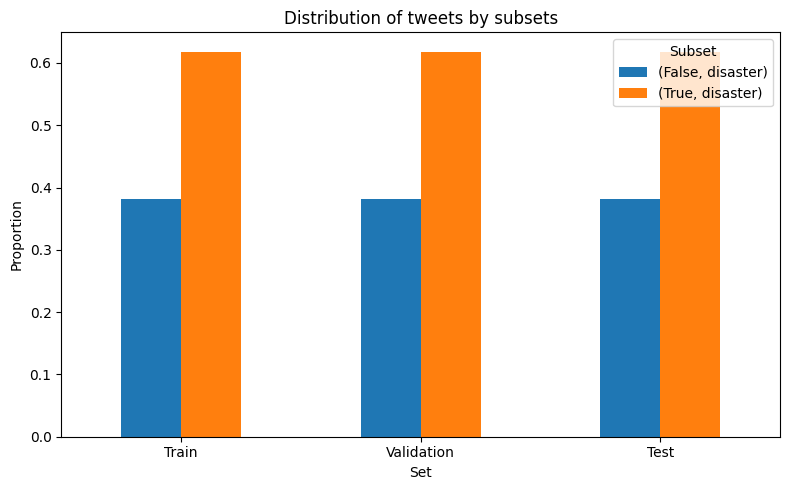

Weather ratio: 1, Out-topic ratio: 0
Weather samples: 2578
Weather experiment samples: 2578
Out-topic samples: 177720
Out-topic experiment samples: 0
Experiment Dataset size: 16954
13563
1695
1696
Train: 80.00%
Validation: 10.00%
Test: 10.00%


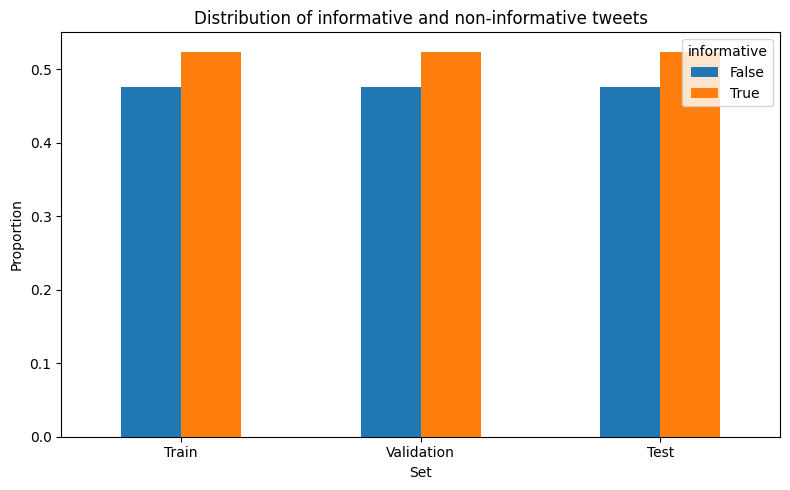

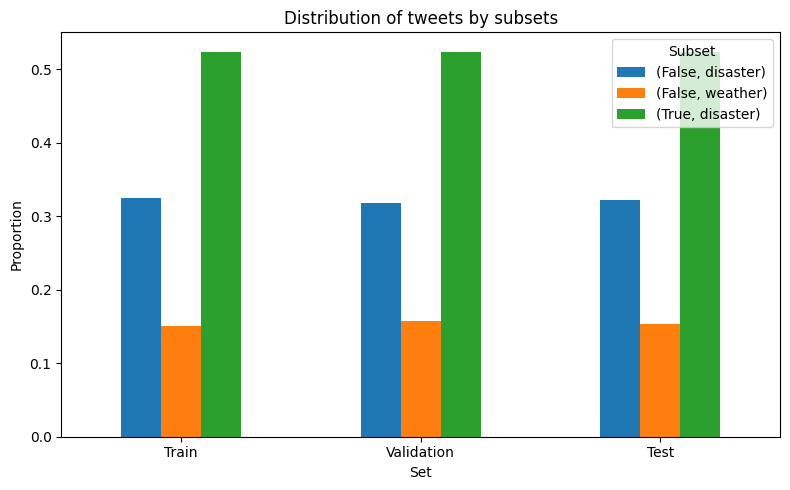

Weather ratio: 1, Out-topic ratio: 0.085494
Weather samples: 2578
Weather experiment samples: 2578
Out-topic samples: 177720
Out-topic experiment samples: 15194
Experiment Dataset size: 32148
25718
3215
3215
Train: 80.00%
Validation: 10.00%
Test: 10.00%


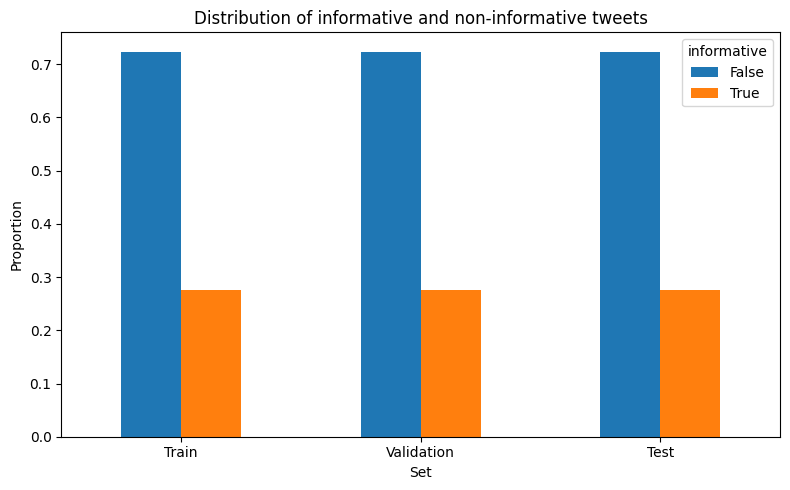

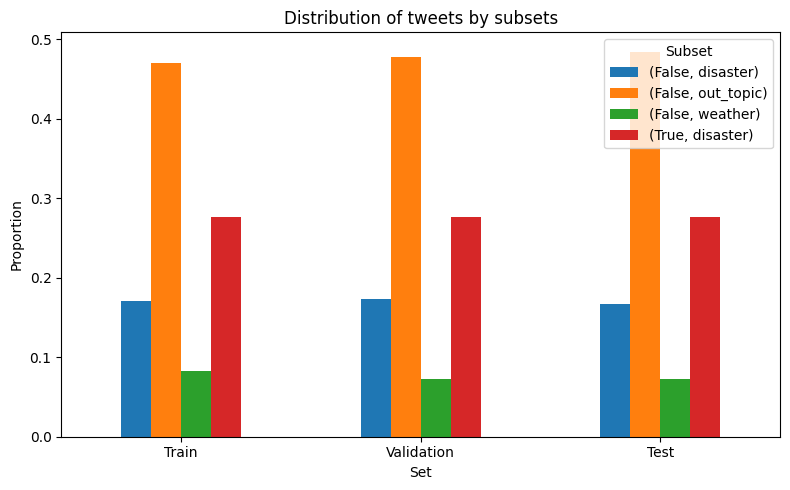

Weather ratio: 1, Out-topic ratio: 0.135494
Weather samples: 2578
Weather experiment samples: 2578
Out-topic samples: 177720
Out-topic experiment samples: 24080
Experiment Dataset size: 41034
32827
4103
4104
Train: 80.00%
Validation: 10.00%
Test: 10.00%


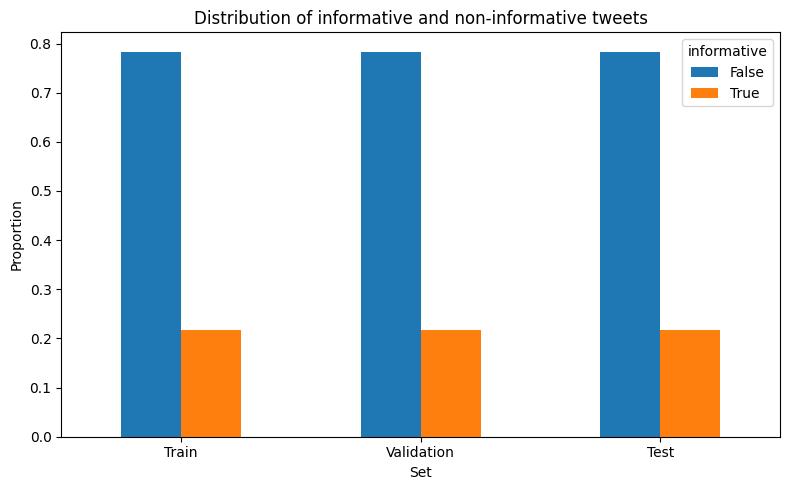

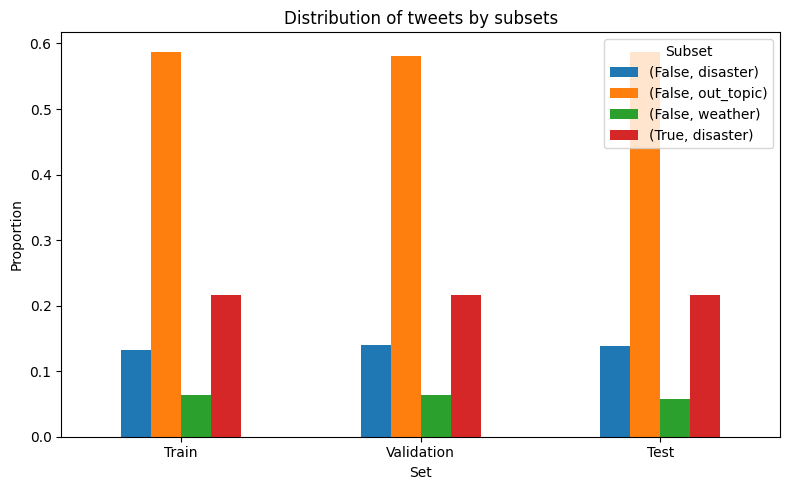

Weather ratio: 1, Out-topic ratio: 0.235494
Weather samples: 2578
Weather experiment samples: 2578
Out-topic samples: 177720
Out-topic experiment samples: 41852
Experiment Dataset size: 58806
47044
5881
5881
Train: 80.00%
Validation: 10.00%
Test: 10.00%


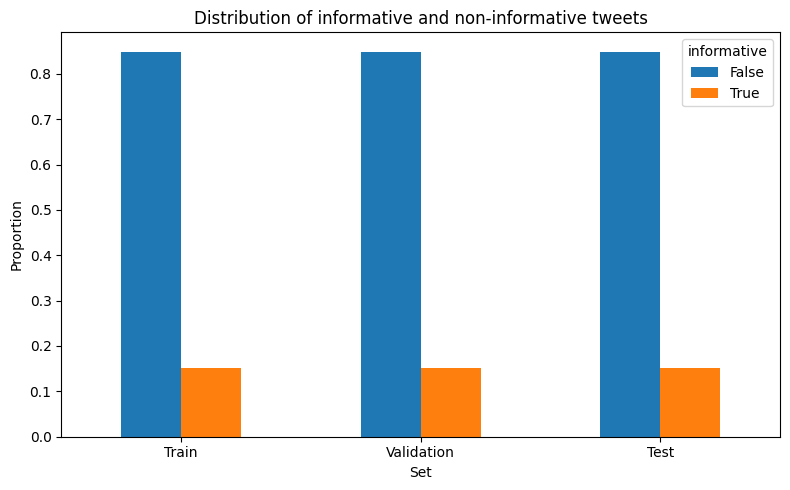

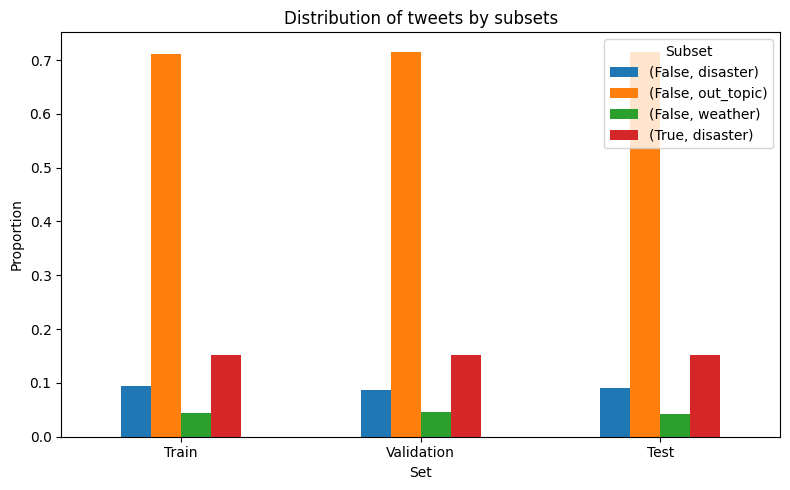

Weather ratio: 1, Out-topic ratio: 0.485494
Weather samples: 2578
Weather experiment samples: 2578
Out-topic samples: 177720
Out-topic experiment samples: 86282
Experiment Dataset size: 103236
82588
10324
10324
Train: 80.00%
Validation: 10.00%
Test: 10.00%


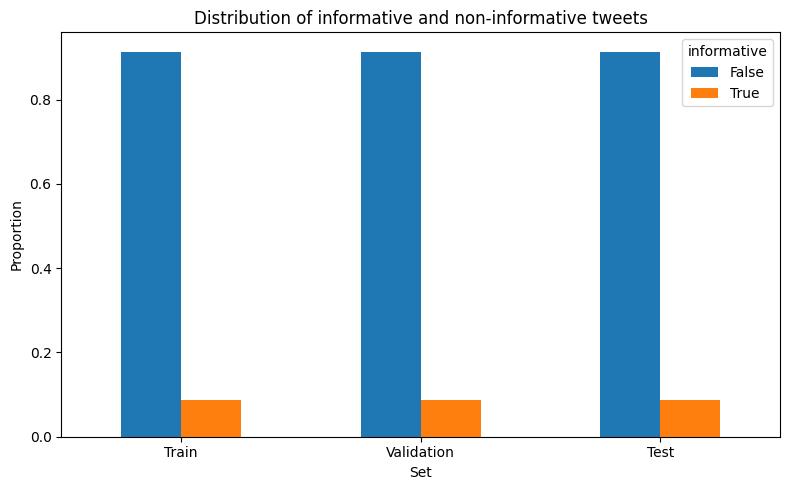

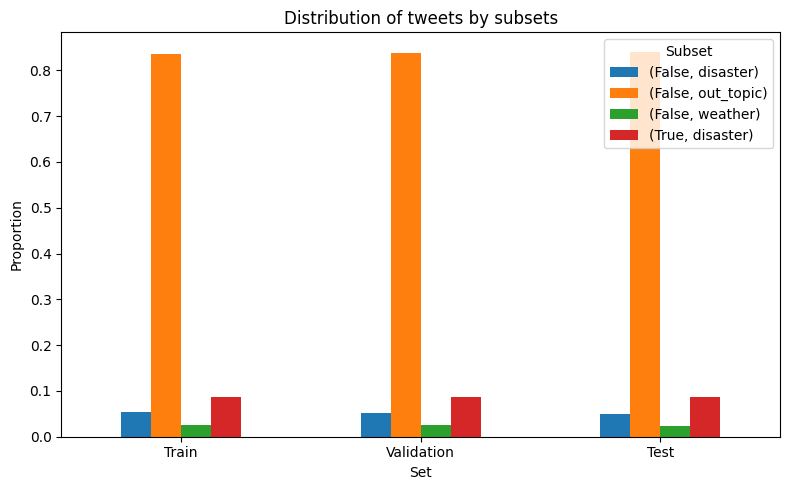

Weather ratio: 1, Out-topic ratio: 0.735494
Weather samples: 2578
Weather experiment samples: 2578
Out-topic samples: 177720
Out-topic experiment samples: 130712
Experiment Dataset size: 147666


118132
14767
14767
Train: 80.00%
Validation: 10.00%
Test: 10.00%


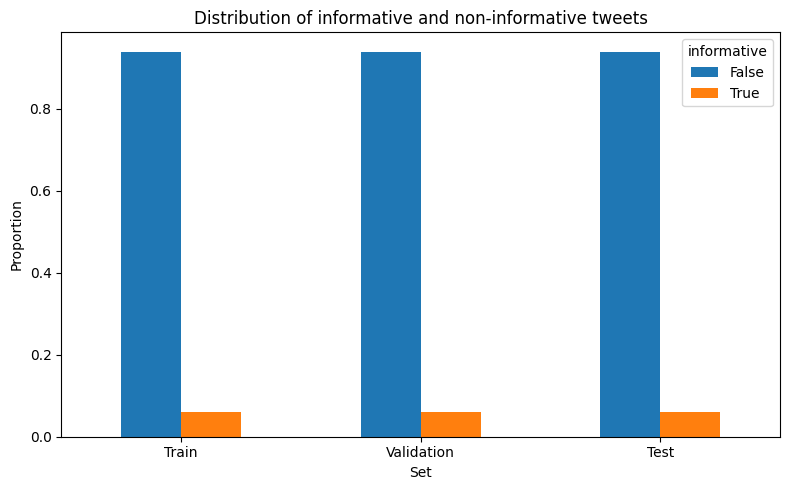

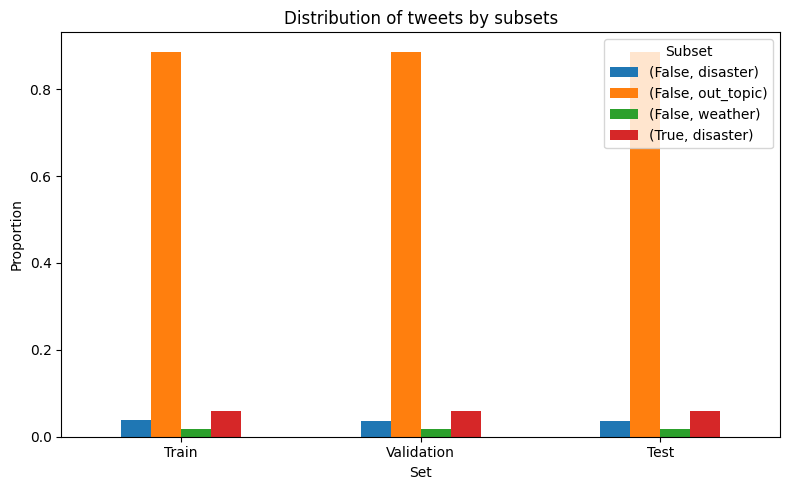

Weather ratio: 1, Out-topic ratio: 0.985494
Weather samples: 2578
Weather experiment samples: 2578
Out-topic samples: 177720
Out-topic experiment samples: 175142
Experiment Dataset size: 192096
153676
19210
19210
Train: 80.00%
Validation: 10.00%
Test: 10.00%


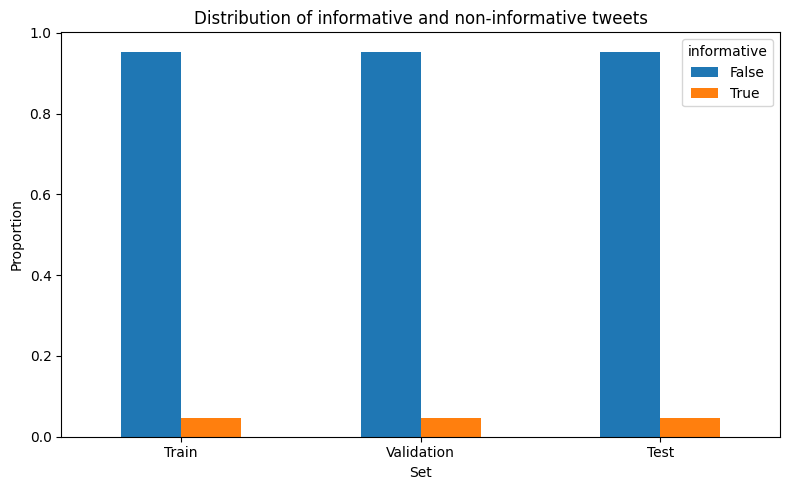

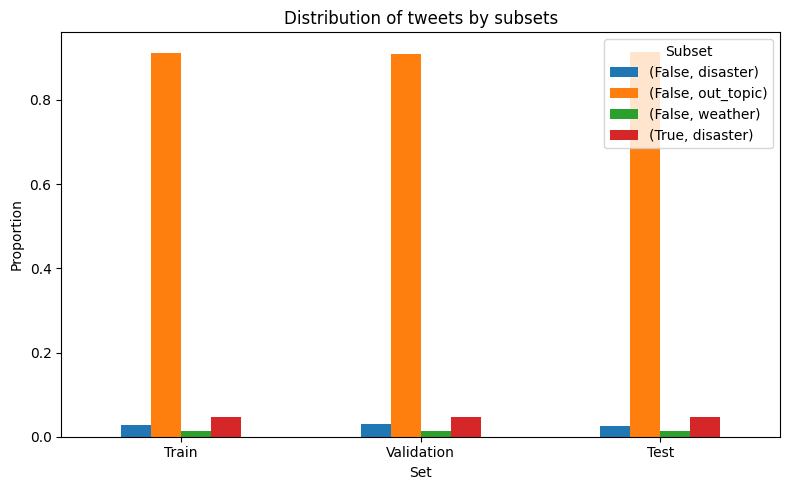

In [6]:
for weather_ratio, out_topic_ratio in data_utils.EXPERIMENT_RATIOS:
    df_experiment = create_experiment_datasets(
        df_disaster,
        df_weather,
        df_out_topic,
        weather_ratio,
        out_topic_ratio,
    )

    print(f"Experiment Dataset size: {len(df_experiment)}")

    save_path = (
        dataset_path
        / "splitted" / 'BERT'
        / data_utils.get_experiment_ratios_path(weather_ratio, out_topic_ratio)
    )

    dist, subset_dist = split_then_export_datasets(df_experiment, save_path=save_path)

    ax = dist.T.plot(kind="bar", figsize=(8, 5), rot=0)
    ax.set_xlabel("Set")
    ax.set_ylabel("Proportion")
    ax.set_title("Distribution of informative and non-informative tweets")
    ax.legend(title="informative")
    plt.tight_layout()
    plt.show()

    ax = subset_dist.T.plot(kind="bar", figsize=(8, 5), rot=0)
    ax.set_xlabel("Set")
    ax.set_ylabel("Proportion")
    ax.set_title("Distribution of tweets by subsets")
    ax.legend(title="Subset")
    plt.tight_layout()
    plt.show()